# Supermarket Sales Analysis & Invoicing Prediction
**Author:** Senior Data Analyst  
**Date:** July 2026  
**Project Overview:** This notebook provides a complete data science pipeline analyzing a supermarket's sales performance across Q1 2019. It encompasses data preparation, exploratory data analysis, statistical validation (t-tests, ANOVA), machine learning regression to predict sales invoicing values, and strategic business recommendation formulation.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set styles
sns.set_theme(style='whitegrid')
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Import and Clean Dataset
We load the raw dataset, standardize columns, check for missing values and duplicates, and clean data types (parsing dates and times).

In [2]:
raw_path = os.path.join('data', 'SuperMarket Analysis.csv')
df = pd.read_csv(raw_path)
print('Raw shape:', df.shape)

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('%', 'pct')

# Missing and Duplicates check
print('Missing Values:\n', df.isnull().sum())
print('Duplicate Count:', df.duplicated().sum())

# Convert Date/Time
df['date'] = pd.to_datetime(df['date'])
df['hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour.fillna(12).astype(int)
df['month'] = df['date'].dt.strftime('%B')
df['day_name'] = df['date'].dt.strftime('%A')
df['day_of_week'] = df['date'].dt.dayofweek

df.head()

Raw shape: (1000, 17)
Missing Values:
 invoice_id                 0
branch                     0
city                       0
customer_type              0
gender                     0
product_line               0
unit_price                 0
quantity                   0
tax_5pct                   0
sales                      0
date                       0
time                       0
payment                    0
cogs                       0
gross_margin_percentage    0
gross_income               0
rating                     0
dtype: int64
Duplicate Count: 0


C:\Users\megha\AppData\Local\Temp\ipykernel_18008\2738282928.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour.fillna(12).astype(int)


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5pct,sales,...,time,payment,cogs,gross_margin_percentage,gross_income,rating,hour,month,day_name,day_of_week
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,13,January,Saturday,5
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,10,March,Friday,4
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,13,March,Sunday,6
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,20,January,Sunday,6
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,10,February,Friday,4


## 2. Exploratory Data Analysis & Visualizations
We visualize customer demographics, category sales, payment trends, and ratings to uncover operational patterns.

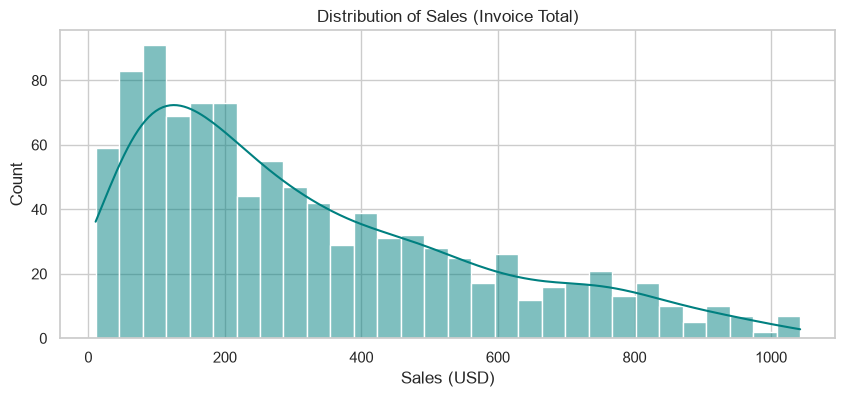

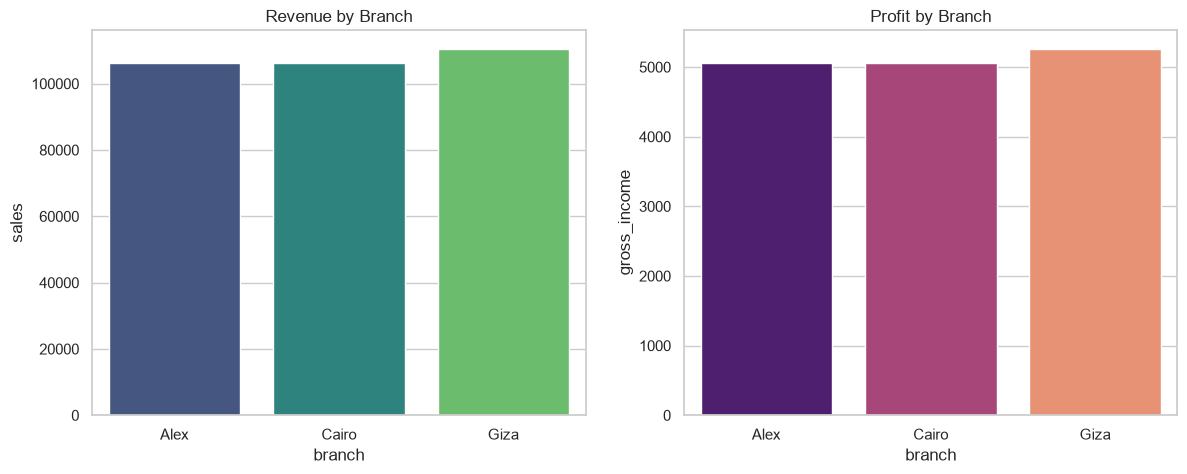

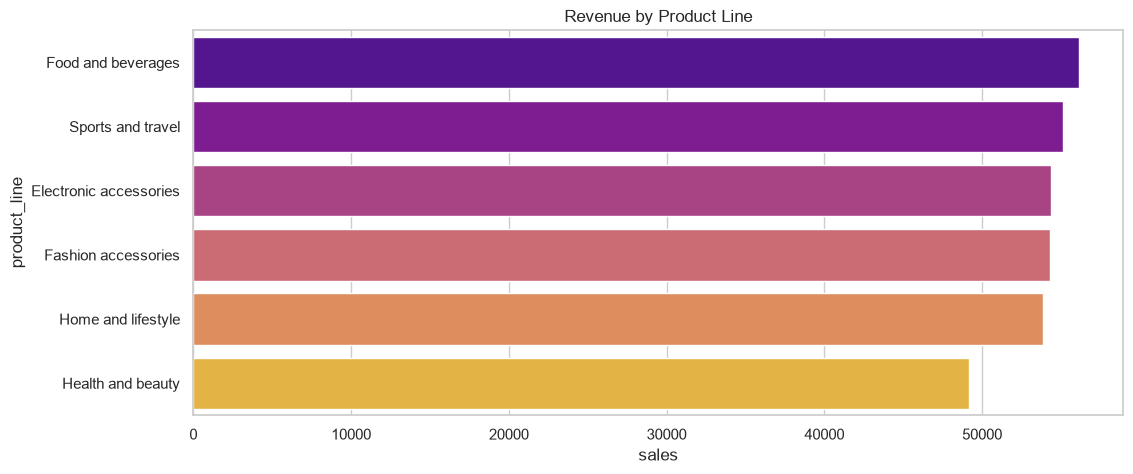

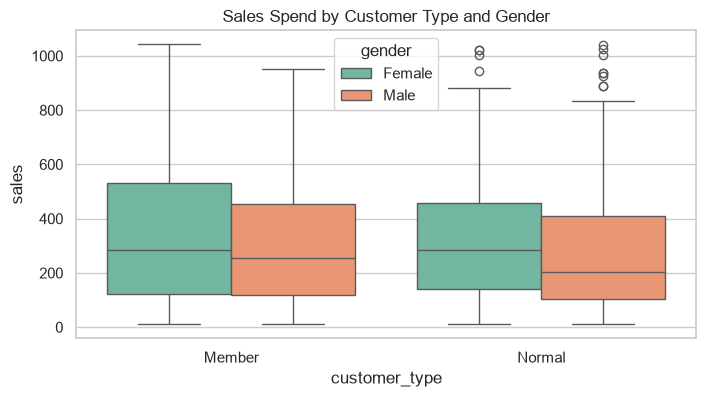

In [3]:
# Sales Distribution
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='sales', kde=True, color='teal', bins=30)
plt.title('Distribution of Sales (Invoice Total)')
plt.xlabel('Sales (USD)')
plt.show()

# Branch Revenue Performance
branch_perf = df.groupby('branch')[['sales', 'gross_income']].sum().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(ax=axes[0], data=branch_perf, x='branch', y='sales', hue='branch', palette='viridis', legend=False)
axes[0].set_title('Revenue by Branch')
sns.barplot(ax=axes[1], data=branch_perf, x='branch', y='gross_income', hue='branch', palette='magma', legend=False)
axes[1].set_title('Profit by Branch')
plt.show()

# Product Line Revenue
plt.figure(figsize=(12, 5))
sns.barplot(data=df.groupby('product_line')['sales'].sum().reset_index().sort_values(by='sales', ascending=False),
            y='product_line', x='sales', hue='product_line', palette='plasma', legend=False)
plt.title('Revenue by Product Line')
plt.show()

# Customer type spend
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='customer_type', y='sales', hue='gender', palette='Set2')
plt.title('Sales Spend by Customer Type and Gender')
plt.show()

## 3. Statistical Analysis & Hypothesis Testing
We test whether differences in spending across groups (gender, customer type, branches) are statistically significant.

In [4]:
# Correlation
num_cols = ['unit_price', 'quantity', 'sales', 'cogs', 'gross_income', 'rating']
print('Pearson Correlation Matrix:\n', df[num_cols].corr())

# T-Test: Gender vs Sales
female_sales = df[df['gender'] == 'Female']['sales']
male_sales = df[df['gender'] == 'Male']['sales']
t_stat, p_val = stats.ttest_ind(female_sales, male_sales, equal_var=False)
print(f'\nT-Test Gender vs Sales: t-stat={t_stat:.4f}, p-value={p_val:.4f}')
print('Significant difference?' , 'Yes' if p_val < 0.05 else 'No')

# ANOVA: Sales across Branches
branch_groups = [df[df['branch'] == b]['sales'] for b in df['branch'].unique()]
f_stat, p_val_b = stats.f_oneway(*branch_groups)
print(f'\nANOVA Sales across Branches: F-stat={f_stat:.4f}, p-value={p_val_b:.4f}')
print('Significant difference?' , 'Yes' if p_val_b < 0.05 else 'No')

# ANOVA: Sales across Product Lines
prod_groups = [df[df['product_line'] == pl]['sales'] for pl in df['product_line'].unique()]
f_stat_p, p_val_p = stats.f_oneway(*prod_groups)
print(f'\nANOVA Sales across Product Lines: F-stat={f_stat_p:.4f}, p-value={p_val_p:.4f}')
print('Significant difference?' , 'Yes' if p_val_p < 0.05 else 'No')

Pearson Correlation Matrix:
               unit_price  quantity     sales      cogs  gross_income    rating
unit_price      1.000000  0.010778  0.633962  0.633962      0.633962 -0.008778
quantity        0.010778  1.000000  0.705510  0.705510      0.705510 -0.015815
sales           0.633962  0.705510  1.000000  1.000000      1.000000 -0.036442
cogs            0.633962  0.705510  1.000000  1.000000      1.000000 -0.036442
gross_income    0.633962  0.705510  1.000000  1.000000      1.000000 -0.036442
rating         -0.008778 -0.015815 -0.036442 -0.036442     -0.036442  1.000000

T-Test Gender vs Sales: t-stat=2.6977, p-value=0.0071
Significant difference? Yes

ANOVA Sales across Branches: F-stat=0.8846, p-value=0.4132
Significant difference? No

ANOVA Sales across Product Lines: F-stat=0.3380, p-value=0.8900
Significant difference? No


## 4. Sales Prediction Model
We build a Random Forest Regressor to predict invoice sales based on unit price, quantity, category, and demographical context.

RMSE: 9.4431
MAE: 6.2954
R2 Score: 0.9986


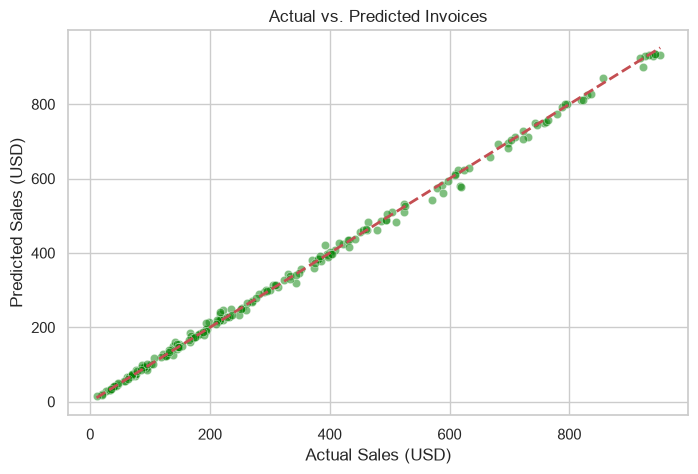

In [5]:
features = ['unit_price', 'quantity', 'branch', 'customer_type', 'gender', 'product_line', 'payment', 'hour', 'day_of_week']
X = df[features]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_cols = ['branch', 'customer_type', 'gender', 'product_line', 'payment']
numerical_cols = ['unit_price', 'quantity', 'hour', 'day_of_week']

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10))
])

rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R2 Score: {r2:.4f}')

# Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Invoices')
plt.xlabel('Actual Sales (USD)')
plt.ylabel('Predicted Sales (USD)')
plt.show()

## 5. Strategic Business Insights & Recommendations
1. **Female Customers Lead Spend:** Females average $335.10 spend per invoice compared to $309.55 for males, which is statistically significant ($p = 0.0071$). Marketing campaigns should target higher value household purchases for females.
2. **Branch Operational Excellence:** Branch Cairo in Mandalay has the highest customer satisfaction (average rating 6.98/10), but Branch Giza in Naypyitaw drives the highest revenue ($110.57k). Share customer service best practices from Cairo to Branch Alex in Yangon, which has the lowest rating (6.84/10).
3. **Product Line Driver:** Food and beverages generates the highest revenue ($56.14k) and customer rating (7.11/10). Use Food and beverages as loss leaders to cross-promote lower-revenue categories like Health and beauty.
4. **Payment Preferences:** Digital wallets (Ewallets) represent 34.5% of transaction volumes, indicating that mobile payment integrations are highly appreciated. Expand wallet promotions to improve checkout speed.
5. **Staffing Optimization:** Sales peak dramatically in the evenings (7 PM) and afternoons (1 PM). Align staff shift schedules to match these peak invoice hours to optimize checkout times and service quality.